# **模块**: 基于PCA的多元统计过程监控
## **课程**: PCA原理剖析
### *主题*:  主成分捕获的方差

In [4]:
# 导入所需包
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [5]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

In [6]:
# 获取数据并探索
df = pd.read_csv('3D_numericalDataset.csv')

print("\n 前几行数据：")
print(df.head())

print("\n\n 基本统计量：")
print(df.describe())


 前几行数据：
         x         y          z
0  0.00000  1.331587  18.674287
1  0.10101  0.816289  18.987328
2  0.20202 -1.343380  21.095214
3  0.30303  0.294646  19.425811
4  0.40404  1.025376  18.563365


 基本统计量：
                x           y           z
count  100.000000  100.000000  100.000000
mean     5.000000    5.079417    9.924043
std      2.930454    3.014944    5.864905
min      0.000000   -1.343380   -0.566620
25%      2.500000    2.753592    5.294487
50%      5.000000    5.077250   10.026243
75%      7.500000    7.390400   14.347033
max     10.000000   10.725989   21.095214


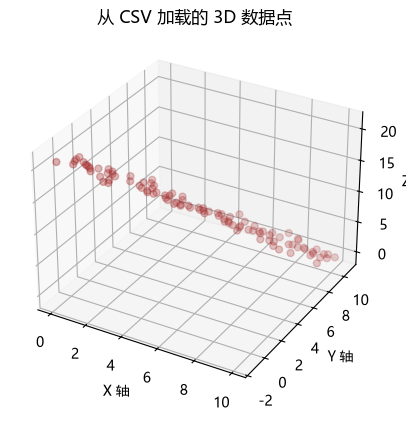

In [7]:
# 绘制数据
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['x'], df['y'], df['z'], c='brown', marker='o', alpha=0.6, s=25)

ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')
ax.set_zlabel('Z 轴')
ax.set_title('从 CSV 加载的 3D 数据点')

plt.show()

In [8]:
# ==================================================================================
#                        拟合PCA模型 
# ==================================================================================

In [9]:
# 将Pandas数据框转换为Numpy数组
data = df.values # can continue working with dataframe as well
print('NumPy 数组：\n', data) 

NumPy 数组：
 [[ 0.          1.3315865  18.67428728]
 [ 0.1010101   0.81628908 18.98732798]
 [ 0.2020202  -1.34338009 21.09521442]
 [ 0.3030303   0.29464645 19.42581082]
 [ 0.4040404   1.02537638 18.56336488]
 [ 0.50505051 -0.21503506 19.68997763]
 [ 0.60606061  0.87157219 18.50756801]
 [ 0.70707071  0.81561923 18.51972049]
 [ 0.80808081  0.81237224 18.41488848]
 [ 0.90909091  0.7344907  18.31705495]
 [ 1.01010101  1.4431272  17.56141883]
 [ 1.11111111  2.31414848 16.55120004]
 [ 1.21212121  0.24705554 18.66103953]
 [ 1.31313131  2.34140539 16.30849546]
 [ 1.41414141  1.64277154 16.9274456 ]
 [ 1.51515152  1.96028913 16.50711526]
 [ 1.61616162  0.4795594  17.88232767]
 [ 1.71717172  1.8523086  16.4375749 ]
 [ 1.81818182  3.30271882 14.89275183]
 [ 1.91919192  0.83938703 17.16049251]
 [ 2.02020202  0.04247374 17.90866857]
 [ 2.12121212  0.37783983 17.43492568]
 [ 2.22222222  2.48829239 15.35129566]
 [ 2.32323232  4.70819965 13.09183428]
 [ 2.42424242  3.54793368 14.09698551]
 [ 2.52525253 

In [10]:
# 缩放数据
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
           
# 拟合PCA（默认保留所有主成分）
pca = PCA()
pca.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [11]:
# 获取各主成分得分的特征值或方差
variances_captured = pca.explained_variance_
print('主成分得分方差：', variances_captured)

主成分得分方差： [2.97666405e+00 5.35916409e-02 4.73420257e-05]


##### 注意方差按递减顺序排列。方差大小可反映主成分的“重要性”。   